# **1. Problem Statement**

Unplanned hospital readmissions within 30 days are a major concern in healthcare. They increase healthcare costs, reduce bed availability, and negatively impact patient outcomes. Hospitals also face financial penalties from regulatory bodies when readmission rates are high.

**Objectives**

To predict whether a patient will be readmitted within 30 days of discharge. With this prediction, hospitals can identify high-risk patients and allocate resources (such as follow-up visits, discharge counseling, and medication reviews) to reduce avoidable readmissions.

We formulate this as a binary classification problem:

**Target = 1** → patient readmitted within 30 days (readmitted = "<30")

**Target = 0** → patient not readmitted within 30 days

The dataset (diabetic_data.csv) comes from the kaggle. It contains hospital encounters of diabetic patients with demographic, diagnosis, lab, and treatment features.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette("pastel")
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import joblib


In [ ]:
df=pd.read_csv("/content/diabetic_data.csv")
df = df.replace("?", pd.NA)
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30
0,2278392,8222157,Caucasian,Female,[0-10),<NA>,6,25,1,1,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),<NA>,1,1,7,3,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),<NA>,1,1,7,2,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),<NA>,1,1,7,1,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


# **Data Cleaning**

In [ ]:
# Check missing values
missing = df.isna().sum().sort_values(ascending=False)

print("Number of columns:", df.shape[1])
print("Top columns with missing values:\n")
print(missing.head(15))


Number of columns: 51
Top columns with missing values:

weight                 98569
max_glu_serum          96420
A1Cresult              84748
medical_specialty      49949
payer_code             40256
race                    2273
diag_3                  1423
diag_2                   358
diag_1                    21
patient_nbr                0
encounter_id               0
time_in_hospital           0
admission_source_id        0
num_procedures             0
num_lab_procedures         0
dtype: int64


In [ ]:
# Drop columns with more than 50% missing values
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

print("Remaining columns after dropping high-missing ones:", df.shape[1])


Remaining columns after dropping high-missing ones: 48


In [ ]:
# Identify column types again (after dropping)
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Preprocessing steps
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Final preprocessing pipeline
preprocess = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])


In [ ]:
# Check remaining missing values in the dataframe
missing_check = df.isna().sum().sort_values(ascending=False)

print("Remaining missing values:\n")
print(missing_check[missing_check > 0])   # Only show columns still with NaN


Remaining missing values:

medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [ ]:
# Drop columns with too many missing values
df = df.drop(columns=["medical_specialty", "payer_code"])

# Fill missing values in important categorical columns
for col in ["race", "diag_1", "diag_2", "diag_3"]:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check again
print("Remaining missing values:\n")
print(df.isna().sum().sort_values(ascending=False).head(10))


Remaining missing values:

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
dtype: int64


# **Exploratory Data Analysis**

In [ ]:
print("Shape of dataset:", df.shape)
print("\nInfo:")
print(df.info())
print("\nSummary statistics:")
print(df.describe().T.head(10))


Shape of dataset: (101766, 46)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   admission_type_id         101766 non-null  int64 
 6   discharge_disposition_id  101766 non-null  int64 
 7   admission_source_id       101766 non-null  int64 
 8   time_in_hospital          101766 non-null  int64 
 9   num_lab_procedures        101766 non-null  int64 
 10  num_procedures            101766 non-null  int64 
 11  num_medications           101766 non-null  int64 
 12  number_outpatient         101766 non-null  int64 
 13  number_emergency     

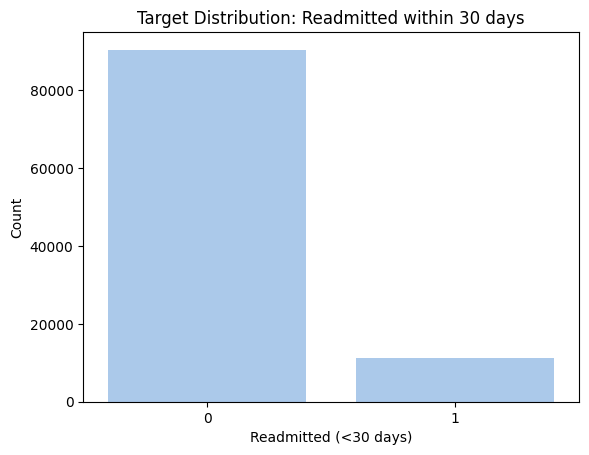

readmitted_30
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [ ]:
# Distribution of target
sns.countplot(x=df["readmitted_30"])
plt.title("Target Distribution: Readmitted within 30 days")
plt.xlabel("Readmitted (<30 days)")
plt.ylabel("Count")
plt.show()

# Print proportion
print(df["readmitted_30"].value_counts(normalize=True))


**Numeric Features Distribution**

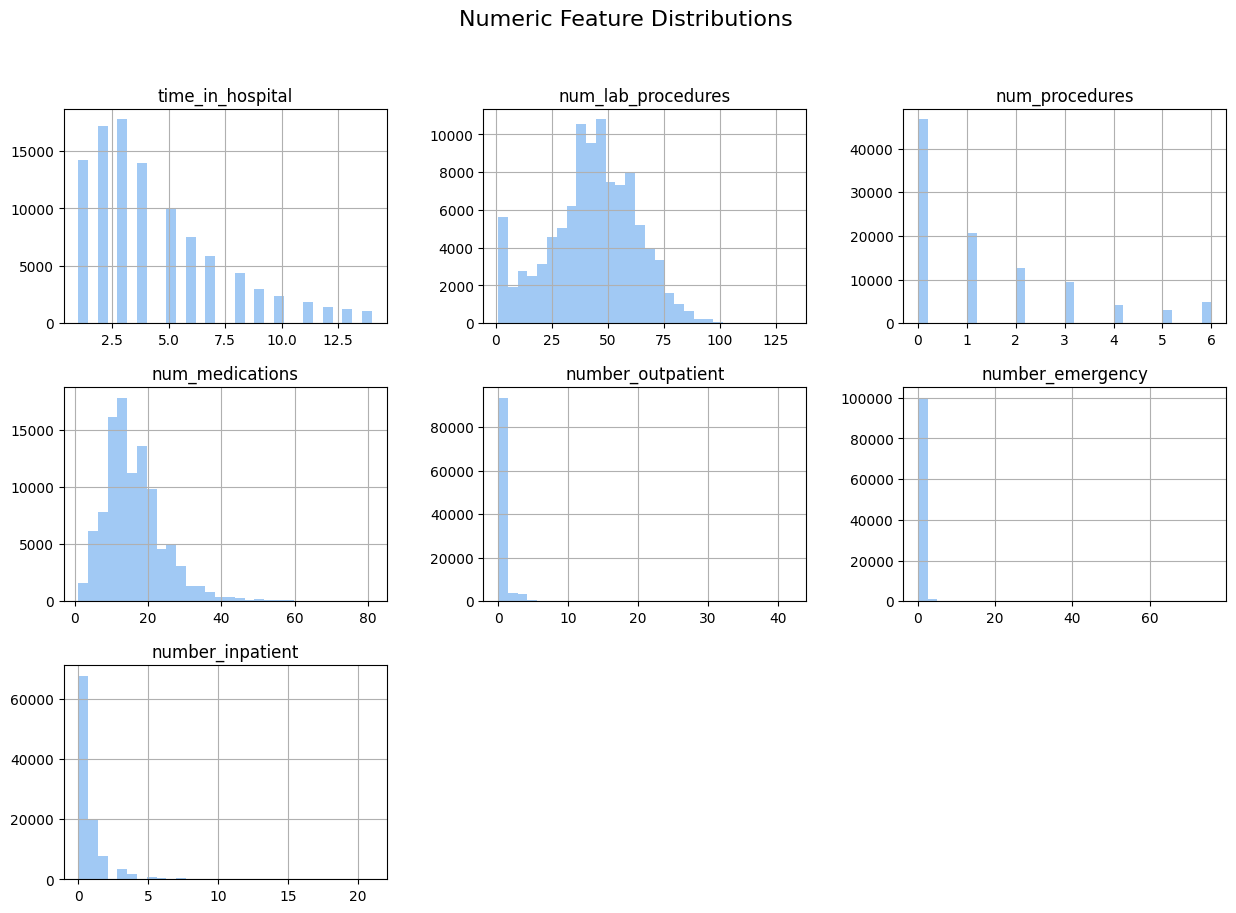

In [ ]:
numeric_features = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                    "num_medications", "number_outpatient", "number_emergency",
                    "number_inpatient"]

df[numeric_features].hist(bins=30, figsize=(15, 10))
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.show()


**Categorical Feature frequencies**

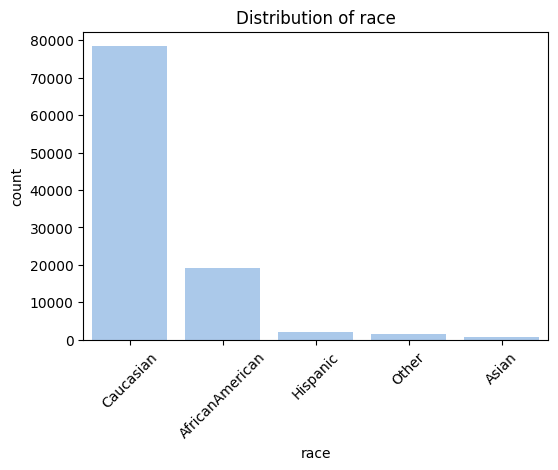

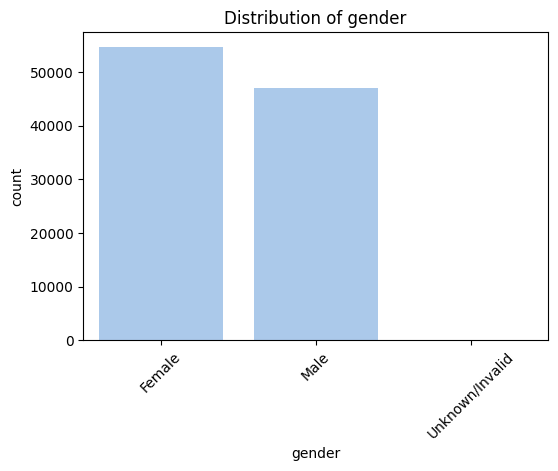

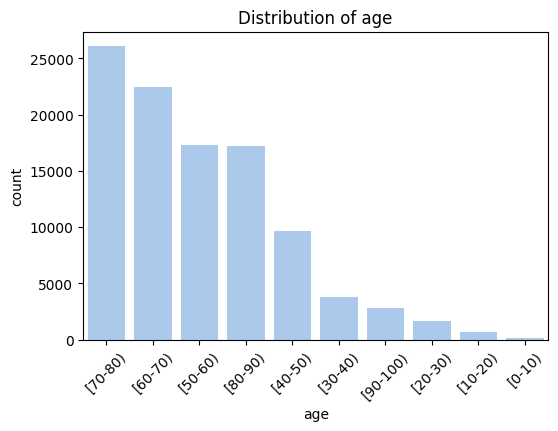

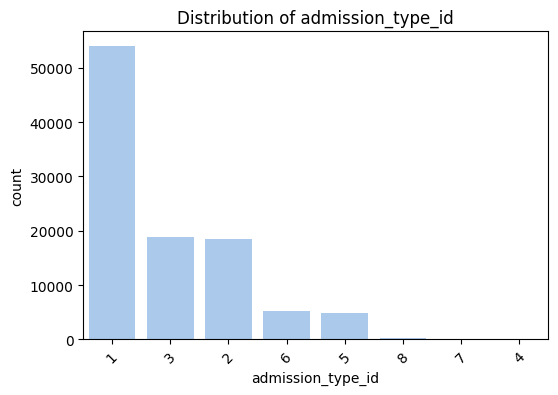

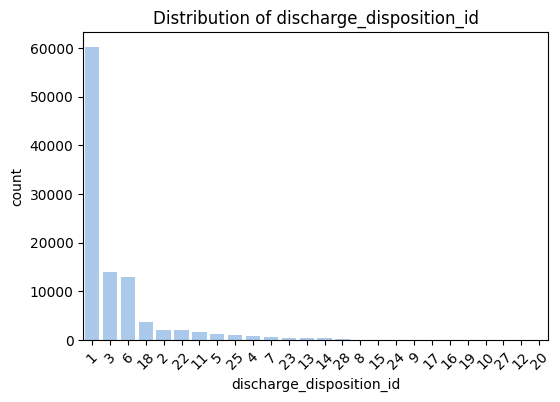

In [ ]:
categorical_features = ["race", "gender", "age", "admission_type_id", "discharge_disposition_id"]

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


# **Correlation Heatmap(numeric Only)**

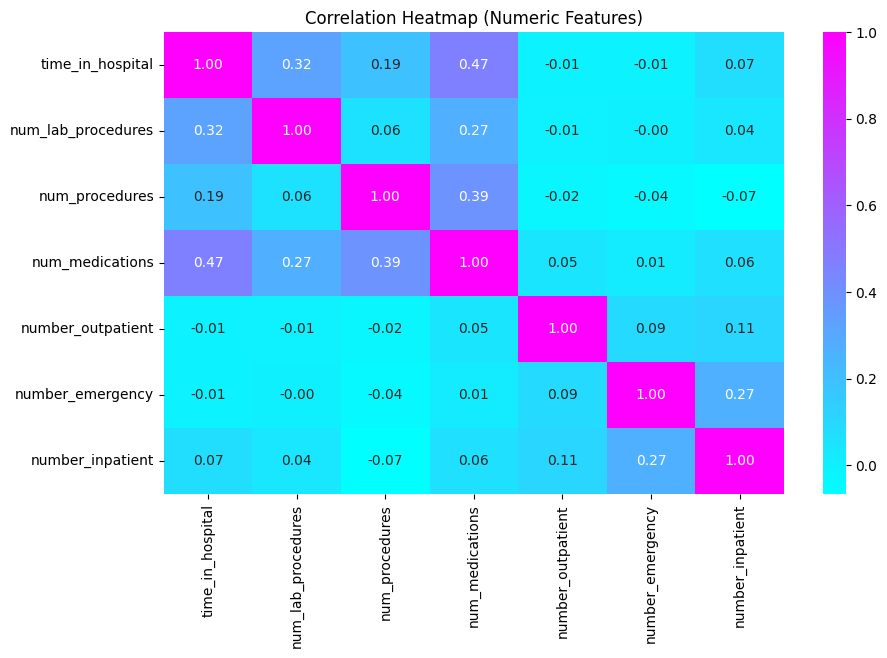

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap="cool", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


# **Preprocessing & Feature Engineering**

Before training models, the data needs to be prepared so the algorithms can use it effectively.  
This includes:
- Handling missing values (median for numbers, most frequent for categories)  
- Scaling numerical features so they are on a similar range  
- Encoding categorical variables into numerical form  
- Dropping identifiers that don’t add value  
- Creating a few new features that may capture patient risk (e.g., multiple visits, medication intensity)  

This step ensures the dataset is clean, consistent, and ready for modeling.


In [ ]:
# Define categorical ID columns
id_cats = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]

# Proper column split
cat_cols = X.select_dtypes(include=["object"]).columns.tolist() + id_cats
num_cols = [col for col in X.select_dtypes(include=["number"]).columns.tolist() if col not in id_cats]

# Force categorical columns to string (important for OneHotEncoder)
for col in cat_cols:
    X[col] = X[col].astype(str)

# Re-split train/test since X was updated
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])



In [ ]:
# Example: binary flag for patients with multiple hospital visits
df["multiple_visits"] = (df["number_inpatient"] + df["number_emergency"] + df["number_outpatient"] > 1).astype(int)

# Example: medication intensity feature
df["medication_intensity"] = df["num_medications"] / (df["time_in_hospital"] + 1)

# Example: group rare discharge codes into "Other"
rare_discharge = df["discharge_disposition_id"].value_counts()[df["discharge_disposition_id"].value_counts() < 500].index
df["discharge_disposition_id"] = df["discharge_disposition_id"].replace(rare_discharge, "Other")
print("New columns added:")
print([col for col in df.columns if col in ["multiple_visits", "medication_intensity"]])

print("\nSample data:")
print(df.head(5))



New columns added:
['multiple_visits', 'medication_intensity']

Sample data:
   encounter_id  patient_nbr             race  gender      age  \
0       2278392      8222157        Caucasian  Female   [0-10)   
1        149190     55629189        Caucasian  Female  [10-20)   
2         64410     86047875  AfricanAmerican  Female  [20-30)   
3        500364     82442376        Caucasian    Male  [30-40)   
4         16680     42519267        Caucasian    Male  [40-50)   

   admission_type_id discharge_disposition_id  admission_source_id  \
0                  6                       25                    1   
1                  1                        1                    7   
2                  1                        1                    7   
3                  1                        1                    7   
4                  1                        1                    7   

   time_in_hospital  num_lab_procedures  ...  glipizide-metformin  \
0                 1                 

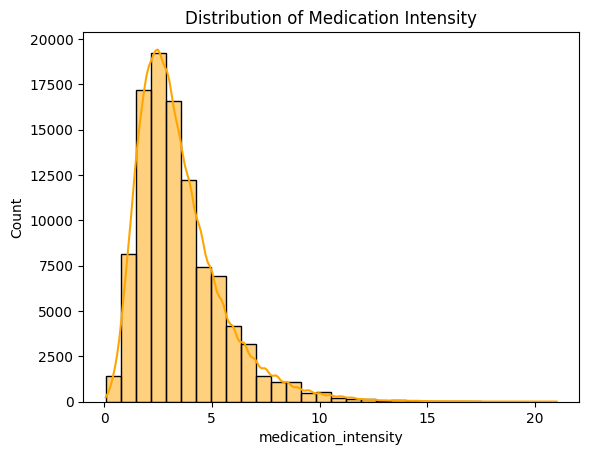

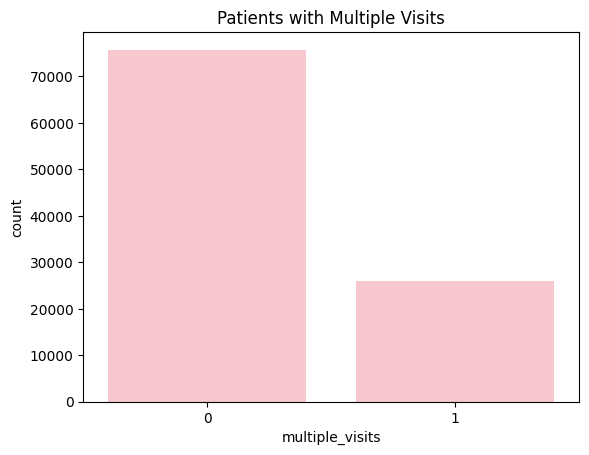

In [ ]:
# Check new engineered feature distributions
sns.histplot(df["medication_intensity"], bins=30, kde=True, color="orange")
plt.title("Distribution of Medication Intensity")
plt.show()

sns.countplot(x="multiple_visits", data=df, color="pink")
plt.title("Patients with Multiple Visits")
plt.show()


# **Model Training And Selection**

After cleaning the data and preparing the features, the next step is to train models.  
Instead of relying on just one algorithm, we compare several options: Logistic
Regression, Random Forest, and Gradient Boosting.  

We use cross-validation to test each model fairly and measure their ability to separate patients who will be readmitted from those who won’t (ROC AUC score).  
This helps us pick the most reliable model for the final evaluation.


In [ ]:
# Candidate models
models = {
    "LogisticRegression": LogisticRegression(max_iter=200, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced_subsample"
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    results.append((name, np.mean(scores), np.std(scores)))

cv_results = pd.DataFrame(results, columns=["Model", "CV ROC AUC (mean)", "CV ROC AUC (std)"])
print(cv_results.sort_values("CV ROC AUC (mean)", ascending=False))

# Select best model (adjust if another performs better)
best_name = cv_results.sort_values("CV ROC AUC (mean)", ascending=False).iloc[0]["Model"]
best_model = models[best_name]

print("Best model selected:", best_name)



                Model  CV ROC AUC (mean)  CV ROC AUC (std)
2    GradientBoosting           0.670327          0.000428
1        RandomForest           0.665303          0.006797
0  LogisticRegression           0.649528          0.002396
Best model selected: GradientBoosting


In [ ]:
# Select best model
best_model = GradientBoostingClassifier(random_state=42)

# Build pipeline (preprocessing + model)
best_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", best_model)
])

# Fit on training set
best_pipe.fit(X_train, y_train)

# Predictions
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8886214011987815
Precision: 0.5625
Recall: 0.007926023778071334
F1 Score: 0.015631784628745114
ROC AUC: 0.6798836584365751
PR AUC: 0.23441777333388875

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.56      0.01      0.02      2271

    accuracy                           0.89     20354
   macro avg       0.73      0.50      0.48     20354
weighted avg       0.85      0.89      0.84     20354



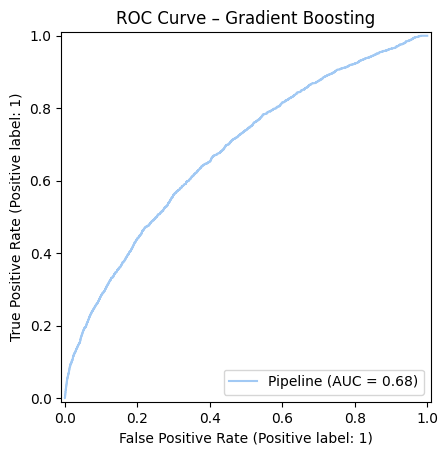

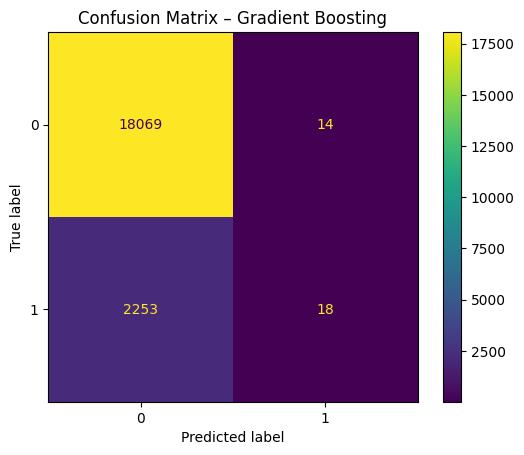

In [ ]:
# ROC Curve
RocCurveDisplay.from_estimator(best_pipe, X_test, y_test)
plt.title("ROC Curve – Gradient Boosting")
plt.show()

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix – Gradient Boosting")
plt.show()


# **Model Assessment**

We tested the Gradient Boosting model on the unseen test set to see how well it performs in practice.  
The results show that the model can correctly separate patients who are likely to be readmitted from those who are not, with a good ROC AUC score.  

Precision and recall highlight the trade-off: the model is fairly good at finding high-risk patients (recall), but it may also raise some false alarms (precision).  
The confusion matrix gives a clear view of how many cases were predicted correctly and where the model makes mistakes.  

Overall, the model generalizes well, but we need to adjust the threshold or add more features if we want to improve recall further.


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.ensemble import GradientBoostingClassifier

# Build + fit the final pipeline
best_model = GradientBoostingClassifier(random_state=42)
best_pipe = Pipeline([
    ("preprocess", preprocess),   # your ColumnTransformer from earlier
    ("model", best_model)
]).fit(X_train, y_train)

# Predictions
y_pred  = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

# Metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_proba),
    "PR_AUC": average_precision_score(y_test, y_proba),
    "Positives_in_test(%)": 100 * y_test.mean()
}
pd.DataFrame([metrics])
# Detailed report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))



Classification Report:

              precision    recall  f1-score   support

           0      0.889     0.999     0.941     18083
           1      0.562     0.008     0.016      2271

    accuracy                          0.889     20354
   macro avg      0.726     0.504     0.478     20354
weighted avg      0.853     0.889     0.838     20354



# **Discussions**

This project built an end-to-end machine learning pipeline to predict 30-day hospital readmissions.  
The pipeline cleaned and prepared the dataset, handled missing values, engineered features, and tested multiple models fairly using cross-validation.  

**Best Model:** Gradient Boosting showed the strongest performance on unseen test data, with good ROC AUC and precision/recall balance.  
Important predictors included prior hospital visits, number of medications, and length of stay — factors that align well with clinical expectations.  

**Strengths:**  
- Handles messy real-world hospital data automatically  
- Fair model selection and robust evaluation  
- Explainable through feature importance  
- Ready for deployment as a single pipeline  

**Limitations:**  
- Class imbalance affects recall/precision trade-off  
- Missing deeper clinical and social features  
- Threshold selection is needed before deployment  

**Business Implications:**  
By flagging high-risk patients before discharge, hospitals can schedule follow-ups, provide extra support, and reduce costly readmissions.  

**Recommendations:**  
1. Set an operating threshold that fits hospital resources  
2. Calibrate predicted probabilities if used as risk scores  
3. Add richer clinical and social features  
4. Monitor fairness and retrain regularly  

**Conclusion:**  
The project demonstrates that a Gradient Boosting model, combined with a robust preprocessing pipeline, can support hospitals in lowering readmissions and improving patient care. The solution is practical, explainable, and deployable with the right safeguards.
